In [1]:
from pathlib import Path
import xarray as xr
import ecco_v4_py as ecco
from xgcm import Grid
import gsw
import matplotlib.pyplot as plt
import cmocean
import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import cartopy.crs as ccrs
from os.path import join,expanduser,exists,split
import glob

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
ECCO_version = 'v4r4'
#ECCO_version = 'v4r5'

if ECCO_version == 'v4r4':
    # v4r4
    ECCO_dir = Path.home() / 'share_disk3/ECCO_products/Version4/Release4'
    grid_file_path = glob.glob(join(ECCO_dir,'*GEOMETRY*','*GEOMETRY*.nc'))[0]
    TS_file_paths           = join(ECCO_dir,'*TEMP_SALINITY*MONTHLY*',f'*.nc')
else: # by default
    ## v4r5
    ECCO_version = 'v4r5'
    ECCO_grid = Path.home() / 'share_disk3/ECCO_products/Version4/Release5/netcdf/native/grid/'
    ECCO_dir = Path.home() / 'share_disk3/ECCO_products/Version4/Release5/netcdf/native/monthly/'
    grid_file_path = glob.glob(join(ECCO_grid,'*GEOMETRY*.nc'))[0]
    TS_file_paths           = join(ECCO_dir,'*TEMPERATURE_SALINITY',f'*.nc')
print(ECCO_version)

v4r4


In [4]:
ds = xr.open_dataset(f'trend_stratification_2k_ECCO{ECCO_version}.nc')
dz_gb_2k = ds.dz_gb_2k
dz_gb_2k_Theta = ds.dz_gb_2k_Theta
dz_gb_2k_Salin = ds.dz_gb_2k_Salin
density_2k = ds.density_2k
OHC_2k = ds.OHC_2k
OSC_2k = ds.OSC_2k
SSD = ds.SSD
SST = ds.SST
SSS = ds.SSS
trend_dz_gb = ds.trend_dz_gb
trend_zg_T = ds.trend_zg_T
trend_zg_S = ds.trend_zg_S
trend_N2 = ds.trend_N2
trend_N2_T = ds.trend_N2_T
trend_N2_S = ds.trend_N2_S
trend_buoyancy = ds.trend_buoyancy
trend_OHC = ds.trend_OHC
trend_OSC = ds.trend_OSC
trend_SSD = ds.trend_SSD
trend_SST = ds.trend_SST
trend_SSS = ds.trend_SSS
pvalue_dz = ds.pvalue_dz
pvalue_zg_T = ds.pvalue_zg_T
pvalue_zg_S = ds.pvalue_zg_S
pvalue_buoyancy = ds.pvalue_buoyancy
pvalue_OHC = ds.pvalue_OHC
pvalue_OSC = ds.pvalue_OSC
pvalue_SSD = ds.pvalue_SSD
pvalue_SST = ds.pvalue_SST
pvalue_SSS = ds.pvalue_SSS

In [5]:
## Load the model grid
ecco_ds = xr.open_mfdataset(grid_file_path,\
                              chunks={'k':50,'tile':13,'j':90,'j_g':90,'i':90,'i_g':90})

In [6]:
# define the metrics
ecco_ds['drW'] = ecco_ds.hFacW * ecco_ds.drF #vertical cell size at u point
ecco_ds['drS'] = ecco_ds.hFacS * ecco_ds.drF #vertical cell size at v point
ecco_ds['drV'] = ecco_ds.rA * ecco_ds.drF # volume at centre and k
ecco_ds['drVg'] = ecco_ds.rAz * ecco_ds.drF # volume at q and k
ecco_ds['drVw'] = ecco_ds.rAw * ecco_ds.drF # volume at q and k
ecco_ds['drVs'] = ecco_ds.rAs * ecco_ds.drF # volume at q and k

metrics = { ('X',): ['dxC', 'dxG'], # X distances
    ('Y',): ['dyC', 'dyG'], # Y distances
    ('Z',): ['drW', 'drS', 'drC','drF'], # Z distances
    ('X', 'Y'): ['rA', 'rAz', 'rAs', 'rAw'], #Areas
    ('X', 'Y','Z'): ['drV','drVg','drVs','drVw']} #volumes

grid = Grid(ecco_ds,periodic=False, metrics=metrics)

In [7]:
globmask = ecco_ds.hFacC.where(ecco_ds.hFacC==0,1)
total_volume = grid.integrate(globmask,['X','Y','Z']).sum('tile').compute()
centre_volume = grid.integrate(ecco_ds.Z*globmask ,['X','Y','Z']).sum('tile') / total_volume
profile_volume = grid.integrate(ecco_ds.hFacC,['X','Y']).sum('tile').compute()
local_depth = grid.integrate(globmask,['Z'])

g = 9.81
rho0 = 1026

In [8]:
H2 = grid.integrate(ecco_ds.maskC.where(ecco_ds.Z>-2000),'Z') #Integrating the maskC field over the vertical dimension Z
maskC_2000 = ecco_ds.maskC.where(ecco_ds.Z>-2000).where(H2==np.max(H2))
volume_2000 = grid.integrate(maskC_2000,['X','Y','Z']).sum('tile').compute()
surface_2000 = grid.integrate(ecco_ds.maskC.isel(k=0).where(H2==np.max(H2)),['X','Y']).sum('tile')

In [9]:
area = grid.get_metric(trend_dz_gb, ("X", "Y"))

### spatial correlations

In [10]:
from scipy import stats

def weighted_corr_p(a: xr.DataArray,
                    b: xr.DataArray,
                    weights: xr.DataArray,
                    dims=None):
    """
    Area-weighted Pearson correlation and two-sided p-value.

    Parameters
    ----------
    a, b : xr.DataArray
        Fields on the same grid.
    weights : xr.DataArray
        Positive weights (e.g., cell area), broadcastable to a/b.
    dims : str or list[str], optional
        Dimensions to reduce over (default: all dims of `weights`).

    Returns
    -------
    r : xr.DataArray
        Weighted correlation.
    p : xr.DataArray
        Two-sided p-value for H0: r=0 using t-test with Kish N_eff.
    """
    # --- align & choose dims
    a, b, w = xr.align(a, b, weights, join="inner")
    if dims is None:
        dims = list(w.dims)
    elif isinstance(dims, str):
        dims = [dims]

    # --- mask invalids & nonpositive weights
    valid = xr.ufuncs.isfinite(a) & xr.ufuncs.isfinite(b) & xr.ufuncs.isfinite(w) & (w > 0)
    a, b, w = a.where(valid), b.where(valid), w.where(valid)

    # --- weighted means
    wsum = w.sum(dims)
    a_bar = (w * a).sum(dims) / wsum
    b_bar = (w * b).sum(dims) / wsum

    # --- weighted covariance & variances
    da, db = a - a_bar, b - b_bar
    cov_ab = (w * da * db).sum(dims) / wsum
    var_a  = (w * da * da).sum(dims) / wsum
    var_b  = (w * db * db).sum(dims) / wsum

    # --- correlation
    denom = xr.ufuncs.sqrt(var_a * var_b)
    r = cov_ab / denom
    r = r.where(denom > 0).compute().values  # avoid divide-by-zero

    # Estimate effective N
    if weights is None:
        # fallback: assume N = total count of valid points
        N_eff = np.count_nonzero(np.isfinite(r))
    else:
        N_eff = ((w.sum()**2 / (w**2).sum())).compute().values # scalar

    df = max(N_eff - 2, 1)
    t = r * np.sqrt(df / (1 - r**2))
    pval = 2 * (1 - stats.t.cdf(np.abs(t), df))

    return r, pval


In [11]:
def weighted_corr_matrix(list1, list2, weights, dims=None):
    """
    Compute a DataFrame of weighted correlations between two lists of DataArrays.

    Parameters
    ----------
    list1, list2 : list[xr.DataArray]
        DataArrays to correlate. Names (da.name) are used for row/column labels.
    weights : xr.DataArray
        Weights for area-weighted correlation.
    dims : str or list[str], optional
        Dimensions to reduce over (default: all dims of weights).

    Returns
    -------
    corr_df : pd.DataFrame
        Correlation values with rows = list1 names, columns = list2 names.
    pval_df : pd.DataFrame
        Corresponding p-values.
    """
    from collections import defaultdict

    corr_vals = defaultdict(dict)
    pval_vals = defaultdict(dict)

    for da1 in list1:
        for da2 in list2:
            r, p = weighted_corr_p(da1, da2, weights, dims=dims)
            # Ensure scalar or small DataArray reduced over dims
            r_val = float(r.compute()) if hasattr(r, "compute") else float(r)
            p_val = float(p.compute()) if hasattr(p, "compute") else float(p)
            corr_vals[da1.name][da2.name] = r_val
            pval_vals[da1.name][da2.name] = p_val

    corr_df = pd.DataFrame(corr_vals).T[list(map(lambda x: x.name, list2))]
    pval_df = pd.DataFrame(pval_vals).T[list(map(lambda x: x.name, list2))]

    return corr_df, pval_df


In [12]:
list1 = [-trend_dz_gb,trend_N2]
list2 = [trend_buoyancy,trend_OHC,trend_OSC,-trend_SSD,trend_SST,trend_SSS]

corr_df, _ = weighted_corr_matrix(list1,list2,area)
corr_df

,trend_buoyancy,trend_OHC,trend_OSC,trend_SSD,trend_SST,trend_SSS
trend_dz_gb,0.856917,0.462375,-0.313872,0.450714,0.383526,-0.188102
trend_N2,0.573491,0.191713,-0.399323,0.690990,0.408290,-0.441172


In [13]:
def df_to_latex_simple(df, caption=None, label=None, float_fmt=".3f"):
    """
    Convert a pandas DataFrame to a LaTeX tabular environment.
    """
    latex = df.to_latex(
        index=True,
        float_format=lambda x: f"{x:{float_fmt}}",
        caption=caption,
        label=label,
        escape=True,
        na_rep=""
    )
    return latex


In [14]:
print(df_to_latex_simple(corr_df, caption="Example correlation table", label="tab:corr"))

\begin{table}
\caption{Example correlation table}
\label{tab:corr}
\begin{tabular}{lrrrrrr}
\toprule
 & trend\_buoyancy & trend\_OHC & trend\_OSC & trend\_SSD & trend\_SST & trend\_SSS \\
\midrule
trend\_dz\_gb & 0.857 & 0.462 & -0.314 & 0.451 & 0.384 & -0.188 \\
trend\_N2 & 0.573 & 0.192 & -0.399 & 0.691 & 0.408 & -0.441 \\
\bottomrule
\end{tabular}
\end{table}



In [15]:
r, p = weighted_corr_p(-trend_dz_gb, trend_N2, area, dims=["tile","j","i"])
print('spatial correlation: ','trend_Dcom vs trend_N2',f'{r}','pvalue = ',f'{p}')

spatial correlation:  trend_Dcom vs trend_N2 0.7145581097526251 pvalue =  0.0


### plot Figure 4

In [16]:
def field_change(
    da_tiled: xr.DataArray,
    *,
    description: str = None,
    units: str = None,
    # target grid (edit as you like)
    min_lat: float = -90,
    max_lat: float = 90,
    dlat: float = 1,
    min_lon: float = -180,
    max_lon: float = 180,
    dlon: float = 1,
    # resampling controls
    radius_of_influence: float = 120000,
    mapping_method: str = "nearest_neighbor",
    neighbors: int = 9,
    fill_value=np.nan,
) -> xr.DataArray:
    """
    Resample an ECCO tiled field (tile, j, i) to a regular lat-lon grid and
    return as an xarray.DataArray with attributes.

    Parameters
    ----------
    da_tiled : xr.DataArray
        Must have dims ('tile','j','i') and coords 'XC','YC' shaped like the data.
    description : str
        Text for da.attrs['description'].
    units : str
        Text for da.attrs['units'].
    min_lat, max_lat, dlat, min_lon, max_lon, dlon : float
        Output grid definition (inclusive bounds, regular spacing).
    radius_of_influence : float
        Search radius in meters for source points.
    mapping_method : {"bin_average","nearest_neighbor"}
        See `ecco.resample_to_latlon`.
    neighbors : int
        # of neighbors for certain mapping methods.
    fill_value : number
        Value to fill where no source points map (default: NaN).

    Returns
    -------
    xr.DataArray (lat, lon)
    """

    # sanity checks
    required = ("tile", "j", "i")
    for d in required:
        if d not in da_tiled.dims:
            raise ValueError(f"Input must have dims {required}, got {da_tiled.dims}")

    if not {"XC", "YC"}.issubset(da_tiled.coords):
        raise ValueError("Input must carry 'XC' and 'YC' coordinates on (tile,j,i).")

    # pull lon/lat source grids (same shape as data)
    orig_lons = da_tiled["XC"].values
    orig_lats = da_tiled["YC"].values

    # source field
    orig_field = da_tiled.values  # works with NumPy or dask-backed arrays

    # call ECCO resampler
    # Note: ecco.resample_to_latlon returns (tgt_lons, tgt_lats, field_on_latlon, weight/count/None)
    tgt_lons, tgt_lats, _ , _ ,field_ll = ecco.resample_to_latlon(
        orig_lons=orig_lons,
        orig_lats=orig_lats,
        orig_field=orig_field,
        new_grid_min_lat=min_lat,
        new_grid_max_lat=max_lat,
        new_grid_delta_lat=dlat,
        new_grid_min_lon=min_lon,
        new_grid_max_lon=max_lon,
        new_grid_delta_lon=dlon,
        radius_of_influence=radius_of_influence,
        fill_value=fill_value,
        mapping_method=mapping_method,
        neighbors=neighbors,
    )

    lon = tgt_lons[0,:]
    lat = tgt_lats[:,0]
    
    # ensure np.ndarray (in case the lib returns masked arrays)
    data = np.asarray(field_ll)
    
    # dimensions will be (lat, lon) to match the 1D coords returned
    da_out = xr.DataArray(
        data,
        dims=("latitude", "longitude"),
        coords={
            "latitude": lat,  # 1D
            "longitude": lon,  # 1D
        },
        name=getattr(da_tiled, "name", None) or "field_change",
        attrs={
            **{k: v for k, v in da_tiled.attrs.items() if k not in ("description", "units")},
            **({"description": description} if description is not None else {}),
            **({"units": units} if units is not None else {}),
            "mapping_method": mapping_method,
            "radius_of_influence_m": radius_of_influence,
            "source_grid": "ECCO tiled (tile,j,i)",
        },
    )

    return da_out


In [17]:
import matplotlib.ticker as ticker
from matplotlib.ticker import MaxNLocator

In [18]:
da1 = field_change(-trend_dz_gb, description="", units="mm year$^{-1}$")
da2 = field_change(-trend_zg_T, description="", units="mm year$^{-1}$")
da3 = field_change(-trend_zg_S, description="", units="mm year$^{-1}$")

In [56]:
print('mean D_COM   value = ',da1.weighted((da1/da1).fillna(0)*np.cos(da1.latitude*np.pi/180)).mean().values)
print('mean D_COM_T value = ',da2.weighted((da1/da1).fillna(0)*np.cos(da1.latitude*np.pi/180)).mean().values)
print('mean D_COM_S value = ',da3.weighted((da1/da1).fillna(0)*np.cos(da1.latitude*np.pi/180)).mean().values)

mean D_COM   value =  0.3644302383219427
mean D_COM_T value =  0.31553173116603694
mean D_COM_S value =  0.04744389405582823


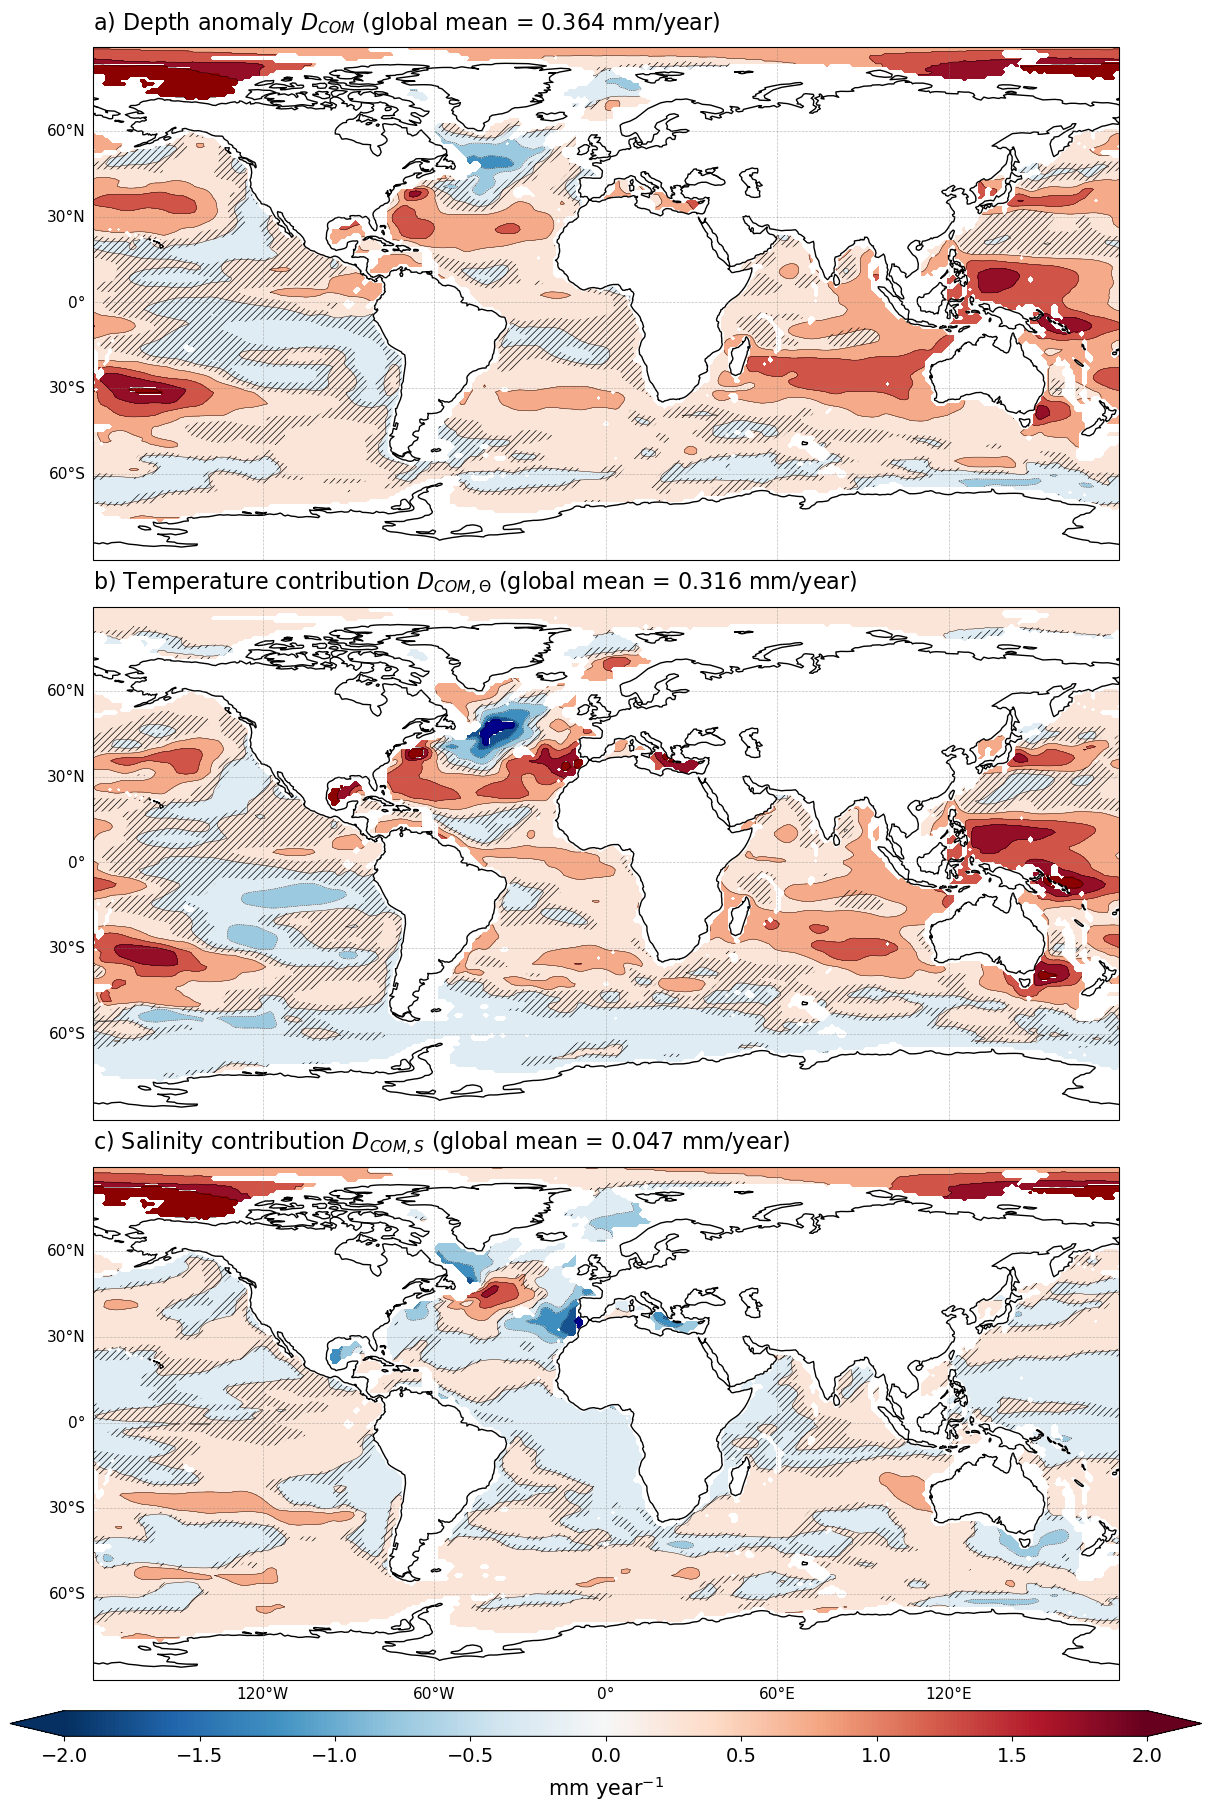

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

plt.rcParams['hatch.linewidth'] = .5

contour_levels = np.linspace(-2, 2, 9)
titles = [
    f"a) Depth anomaly $D_{{COM}}$ (global mean = {da1.weighted((da1/da1).fillna(0)*np.cos(da1.latitude*np.pi/180)).mean().values:3.3g} mm/year)",
    f"b) Temperature contribution $D_{{COM,\\Theta}}$ (global mean = {da2.weighted((da1/da1).fillna(0)*np.cos(da1.latitude*np.pi/180)).mean().values:3.3g} mm/year)",
    f"c) Salinity contribution $D_{{COM,S}}$ (global mean = {da3.weighted((da1/da1).fillna(0)*np.cos(da1.latitude*np.pi/180)).mean().values:3.3f} mm/year)"
]
trends  = [da1, da2, da3]
pvalues = [pvalue_dz, pvalue_zg_T, pvalue_zg_S]

# ---- Figure 5: 3 map rows + a small cbar row
fig5 = plt.figure(figsize=(12, 18), constrained_layout=True)
gs5 = fig5.add_gridspec(
    nrows=4, ncols=1,
    height_ratios=[1, 1, 1, 0.05]  # last row = colorbar (thin)
)

axes_left = [fig5.add_subplot(gs5[i, 0], projection=ccrs.PlateCarree()) for i in range(3)]
cax = fig5.add_subplot(gs5[3, 0])  # colorbar axis (regular)
#cax.set_axis_off()                 # hide, fig.colorbar will draw into it

for i, (ax, trend, pvalue, title) in enumerate(zip(axes_left, trends, pvalues, titles)):
    da = trend.where(trend != 0)
    masked_da = da.where((da >= -2) & (da <= 2))

    ax.set_facecolor("white")
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = True
    gl.bottom_labels = (i == 2)
    gl.xlabel_style = {"size": 11}
    gl.ylabel_style = {"size": 11}

    cmap = plt.cm.RdBu_r.copy()
    cmap.set_bad(color="white", alpha=0)
    ax.contourf(
        da.longitude, da.latitude, masked_da,
        levels=contour_levels, vmin=-2, vmax=2,
        cmap=cmap, extend='both',
        transform=ccrs.PlateCarree()
    )

    above_limit = da > 2
    below_limit = da < -2
    ax.contourf(da.longitude, da.latitude, above_limit,
                levels=[0.5, 1], colors='darkred', transform=ccrs.PlateCarree())
    ax.contourf(da.longitude, da.latitude, below_limit,
                levels=[0.5, 1], colors='darkblue', transform=ccrs.PlateCarree())

    da_pvalue = field_change(pvalue * 100, description="pvalue", units="%")
    ax.contourf(
        da.longitude, da.latitude, da_pvalue,
        levels=(0, 10, 100), hatches=(None, '/////'),
        colors='none', extend='lower',
        transform=ccrs.PlateCarree()
    )

    ax.contour(
        da.longitude, da.latitude, da,
        levels=contour_levels, colors="black", linewidths=0.3,
        transform=ccrs.PlateCarree()
    )

    ax.coastlines()
    ax.text(0.0, 1.02, title, transform=ax.transAxes, fontsize=16, ha='left', va='bottom')

# ---- Small horizontal colorbar (shorter + thinner) in its own axis
sm = ScalarMappable(norm=Normalize(vmin=-2, vmax=2), cmap="RdBu_r")
sm.set_array([])

cbar = fig5.colorbar(sm, cax=cax, orientation="horizontal", extend="both")
cbar.set_label("mm year$^{-1}$", fontsize=15, labelpad=6)
cbar.ax.tick_params(labelsize=14)
cbar.set_ticks(np.linspace(-2, 2, 9))

fig5.savefig(f'Figure5_ECCO{ECCO_version}.png', dpi=300, bbox_inches='tight')
fig5.savefig(f'Figure5_ECCO{ECCO_version}.pdf', bbox_inches='tight')
plt.show()

## meridional distribution

In [93]:
area = ((da/da).fillna(0).sum('longitude')*np.cos(da.latitude*np.pi/180))
mean_area = area.mean()
norm_area = (area/mean_area)

da11 = da1.mean('longitude')*norm_area
latitude1 = da11['latitude']
values1 = da11.values

da22 = da2.mean('longitude')*norm_area
latitude2 = da22['latitude']
values2 = da22.values

da33 = da3.mean('longitude')*norm_area
latitude3 = da33['latitude']
values3 = da33.values

values4 = values2 + values3 - values1

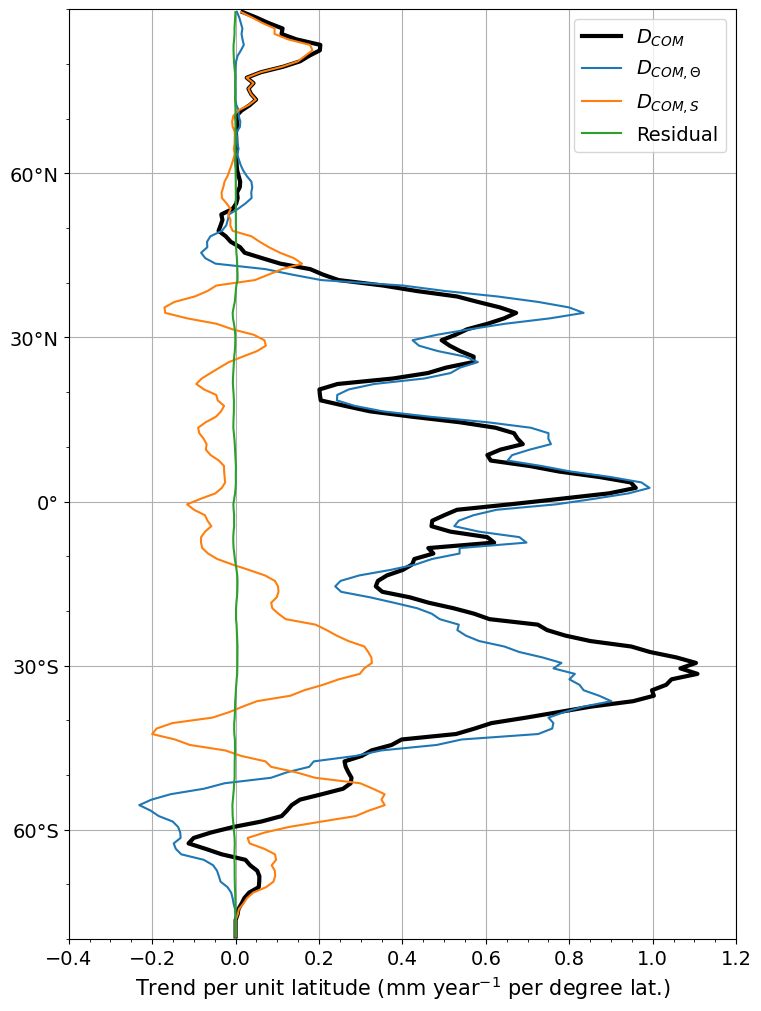

In [99]:
# --------------------------
# FIGURE 6: zonal means only
# --------------------------
fig6, ax = plt.subplots(figsize=(7.5, 10), constrained_layout=True)

ax.tick_params(axis='both', labelsize=14)
ax.plot(values1, latitude1, label='$D_{COM}$', linewidth=3, color='k')
ax.plot(values2, latitude2, label='$D_{COM,\\Theta}$')
ax.plot(values3, latitude3, label='$D_{COM,S}$')
ax.plot(values4, latitude3, label='Residual')

#ax.set_title('Zonal-mean stratification trends', loc='left', fontsize=15)
ax.set_xlabel('Trend per unit latitude (mm year$^{-1}$ per degree lat.)', fontsize=15)
ax.set_xlim(-.4, 1.2)

ax.set_ylim(-80, 90)
ax.set_yticks(np.arange(-60,90,30))
ax.set_yticklabels(['60°S', '30°S', '0°', '30°N', '60°N'])

from matplotlib.ticker import AutoMinorLocator

ax.minorticks_on()
ax.yaxis.set_minor_locator(AutoMinorLocator(3))  # 1 minor between majors

ax.grid(True)
ax.legend(fontsize=14)

fig6.savefig(f'Figure6_ECCO{ECCO_version}.png', dpi=300, bbox_inches='tight')
fig6.savefig(f'Figure6_ECCO{ECCO_version}.pdf', bbox_inches='tight')



In [29]:
# import numpy as np
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# from matplotlib.cm import ScalarMappable
# from matplotlib.colors import Normalize
# plt.rcParams['hatch.linewidth'] = .5

# # --- Figure + layout: 3 rows x 2 cols; right panel spans all rows ---
# fig = plt.figure(figsize=(18, 10), constrained_layout=True)
# gs = fig.add_gridspec(nrows=3, ncols=2, width_ratios=[1, .7], height_ratios=[1, 1, 1])

# axes_left = [fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree()) for i in range(3)]
# ax_right = fig.add_subplot(gs[:, 1])

# # --- Left column: three maps ---
# contour_levels = np.linspace(-2, 2, 9)
# titles = [
#     "a) Depth anomaly $D_{COM}$", 
#     "b) Temperature contribution $D_{COM,\\Theta}$", 
#     "c) Salinity contribution $D_{COM,S}$"
# ]
# trends = [da1, da2, da3]
# pvalues = [pvalue_dz, pvalue_zg_T, pvalue_zg_S]

# for ax, trend, pvalue, title in zip(axes_left, trends, pvalues, titles):
    
#     da = trend.where(trend!=0)
#     masked_da = da.where((da >= -2) & (da <= 2))
    
#     ax.set_facecolor("white")
#     gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
#     gl.top_labels = False
#     gl.right_labels = False
#     gl.left_labels = False
#     gl.bottom_labels = False
#     gl.xlabel_style = {"size": 12}
#     gl.ylabel_style = {"size": 12}
    
#     # Filled contours
#     cmap = plt.cm.RdBu_r.copy()
#     cmap.set_bad(color="white", alpha=0)
#     contour = ax.contourf(
#         da.longitude, da.latitude, masked_da,
#         levels=contour_levels, vmin=-2, vmax=2,
#         cmap=cmap, extend='both',
#         transform=ccrs.PlateCarree()
#     )
    
#     # Values outside range
#     above_limit = da > 2
#     below_limit = da < -2
#     ax.contourf(
#         da.longitude, da.latitude, above_limit,
#         levels=[0.5, 1], colors='darkred', transform=ccrs.PlateCarree()
#     )
#     ax.contourf(
#         da.longitude, da.latitude, below_limit,
#         levels=[0.5, 1], colors='darkblue', transform=ccrs.PlateCarree()
#     )

#     # Stippling from p-values
#     da_pvalue = field_change(pvalue * 100, description="pvalue", units="%")
#     ax.contourf(
#         da.longitude, da.latitude, da_pvalue,
#         levels=(0, 10, 100), hatches=(None, '/////'),
#         colors='none', extend='lower',
#         transform=ccrs.PlateCarree()
#     )

#     # Thin contour lines (no labels)
#     ax.contour(
#         da.longitude, da.latitude, da,
#         levels=contour_levels,
#         colors="black", linewidths=0.3,
#         transform=ccrs.PlateCarree()
#     )

#     ax.coastlines()

#     # Left-justified panel title
#     ax.text(
#         0.0, 1.02, title,
#         transform=ax.transAxes,
#         fontsize=16,
#         ha='left', va='bottom'
#     )

# # Shared colorbar under the three maps (left column only)
# sm = ScalarMappable(norm=Normalize(vmin=-2, vmax=2), cmap="RdBu_r")
# sm.set_array([])
# cbar = fig.colorbar(
#     sm, ax=axes_left, orientation="vertical",
#     fraction=0.03, pad=0.03, extend='both'
# )
# cbar.set_label("mm year$^{-1}$", fontsize=15, labelpad=10, loc="center")
# cbar.ax.xaxis.set_label_position('top')
# cbar.ax.xaxis.set_ticks_position('top')
# cbar.ax.tick_params(labelsize=14)
# cbar.set_ticks(np.linspace(-2, 2, 9))

# # --- Right column: zonal-mean plot ---
# # If you previously set rcParams globally, you can instead control per-axis here:
# ax_right.tick_params(axis='both', labelsize=14)

# ax_right.plot(values1, latitude1, label='$D_{COM}$')
# ax_right.plot(values2, latitude2, label='$D_{COM,\\Theta}$')
# # Using latitude3 for both 3 and 4 to match your original code
# ax_right.plot(values3, latitude3, label='$D_{COM,S}$')
# ax_right.plot(values4, latitude3, label='Residual', color='k')

# ax_right.set_title('d) Zonal-mean stratification trends', loc='left', fontsize=15)
# ax_right.set_xlabel('Trend per unit latitude (mm year$^{-1}$ per degree lat.)', fontsize=15)
# ax_right.set_xlim(-.5, 2)
# ax_right.legend(fontsize=14)

# ax_right.set_ylim(-90,90)
# ax_right.set_yticks([-75, -50, -25, 0, 25, 50, 75])
# ax_right.set_yticklabels(['75°S', '50°S', '25°S', '0°', '25°N', '50°N', '75°N'])
# ax_right.grid(True)

# # --- Save final figure ---
# plt.savefig(f'Figure5_ECCO{ECCO_version}.png', dpi=300, bbox_inches='tight')
# plt.savefig(f'Figure5_ECCO{ECCO_version}.pdf', bbox_inches='tight')
# plt.show()


#### **Ocean Buoyancy Content**

In [31]:
da4 = field_change(trend_buoyancy, description="", units="m\\ s^{-2}\\ m^{-2}\\ year$^{-1}$")
da5 = field_change(trend_OHC, description="", units="J m^{-2}\\ year$^{-1}$")
da6 = field_change(trend_OSC, description="", units="g/kg\\ m^{-2}\\ year$^{-1}$")

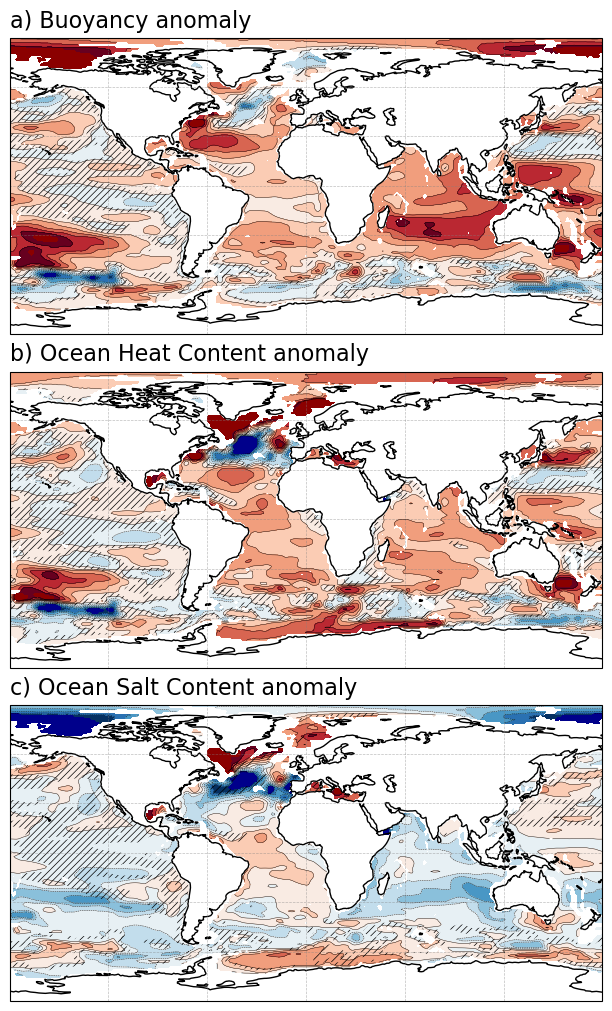

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
plt.rcParams['hatch.linewidth'] = .5

# --- Figure + layout: 3 rows x 2 cols; right panel spans all rows ---
fig = plt.figure(figsize=(18, 10), constrained_layout=True)
gs = fig.add_gridspec(nrows=3, ncols=1, height_ratios=[1, 1, 1])

axes_left = [fig.add_subplot(gs[i], projection=ccrs.PlateCarree()) for i in range(3)]

# --- Left column: three maps ---
contour_levels = np.linspace(-2.5, 2.5, 11)
titles = [
    "a) Buoyancy anomaly", 
    "b) Ocean Heat Content anomaly", 
    "c) Ocean Salt Content anomaly"
]
trends = [da4, da5, da6]
pvalues = [pvalue_buoyancy, pvalue_OHC, pvalue_buoyancy]

for ax, trend, pvalue, title in zip(axes_left, trends, pvalues, titles):
    
    da = trend.where(trend!=0)
    da = da / da.std()
    masked_da = da.where((da >= -3) & (da <= 3))
    
    ax.set_facecolor("white")
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = False
    gl.bottom_labels = False
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}
    
    # Filled contours
    cmap = plt.cm.RdBu_r.copy()
    cmap.set_bad(color="white", alpha=0)
    contour = ax.contourf(
        da.longitude, da.latitude, masked_da,
        levels=contour_levels, vmin=-3, vmax=3,
        cmap=cmap, extend='both',
        transform=ccrs.PlateCarree()
    )
    
    # Values outside range
    above_limit = da > 3
    below_limit = da < -3
    ax.contourf(
        da.longitude, da.latitude, above_limit,
        levels=[0.5, 1], colors='darkred', transform=ccrs.PlateCarree()
    )
    ax.contourf(
        da.longitude, da.latitude, below_limit,
        levels=[0.5, 1], colors='darkblue', transform=ccrs.PlateCarree()
    )

    # Stippling from p-values
    da_pvalue = field_change(pvalue * 100, description="pvalue", units="%")
    ax.contourf(
        da.longitude, da.latitude, da_pvalue,
        levels=(0, 10, 100), hatches=(None, '/////'),
        colors='none', extend='lower',
        transform=ccrs.PlateCarree()
    )

    # Thin contour lines (no labels)
    ax.contour(
        da.longitude, da.latitude, da,
        levels=contour_levels,
        colors="black", linewidths=0.3,
        transform=ccrs.PlateCarree()
    )

    ax.coastlines()

    # Left-justified panel title
    ax.text(
        0.0, 1.02, title,
        transform=ax.transAxes,
        fontsize=16,
        ha='left', va='bottom'
    )

# --- Save final figure ---
plt.savefig(f'FigureA2_ECCO{ECCO_version}.png', dpi=300, bbox_inches='tight')
plt.savefig(f'FigureA2_ECCO{ECCO_version}.pdf', bbox_inches='tight')
plt.show()
